In [3]:
import pandas as pd

In [4]:
# First Load Data

In [5]:
data = pd.read_csv("/content/insurance[1].csv")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
data.duplicated().sum()

np.int64(1)

In [9]:
data.drop_duplicates(inplace = True)

In [10]:
data.rename({"sex":"Gender"}, axis = 1, inplace=True)

In [11]:
data.Gender.value_counts()

,count
Gender,
male,675
female,662


In [12]:
data.smoker.value_counts()

,count
smoker,
no,1063
yes,274


In [13]:
data.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [14]:
# mapping
data["Gender"]=data.Gender.map({"male":1, "female":0})
data.smoker=data.smoker.map({"yes":1, "no":0})
# lambda
data.Gender.apply(lambda x:   1 if x=="male" else 0)
data.smoker.apply(lambda x:   1 if x=="yes" else 0)

,smoker
0,0
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [15]:
encoder_data = pd.get_dummies(data, dtype = int)

In [16]:
encoder_data.describe()

,age,Gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487,0.242334,0.242334,0.272251,0.243082
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656,0.428655,0.428655,0.445285,0.429104
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300,0.000000,0.000000,0.000000,0.000000
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450,0.000000,0.000000,1.000000,0.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010,1.000000,1.000000,1.000000,1.000000


In [17]:
encoder_data.corr()

,age,Gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308,0.001868,0.001495,-0.012311,0.009415
Gender,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044,-0.002008,-0.012482,0.017578,-0.003767
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401,-0.138178,-0.136138,0.270057,-0.006211
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389,-0.023202,0.026044,-0.023492,0.021538
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234,0.002597,-0.036321,0.068282,-0.037168
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000,0.005945,-0.038695,0.073578,-0.043637
region_northeast,0.001868,-0.002008,-0.138178,-0.023202,0.002597,0.005945,1.000000,-0.319842,-0.345909,-0.320493
region_northwest,0.001495,-0.012482,-0.136138,0.026044,-0.036321,-0.038695,-0.319842,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.320493,-0.346614,1.000000


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

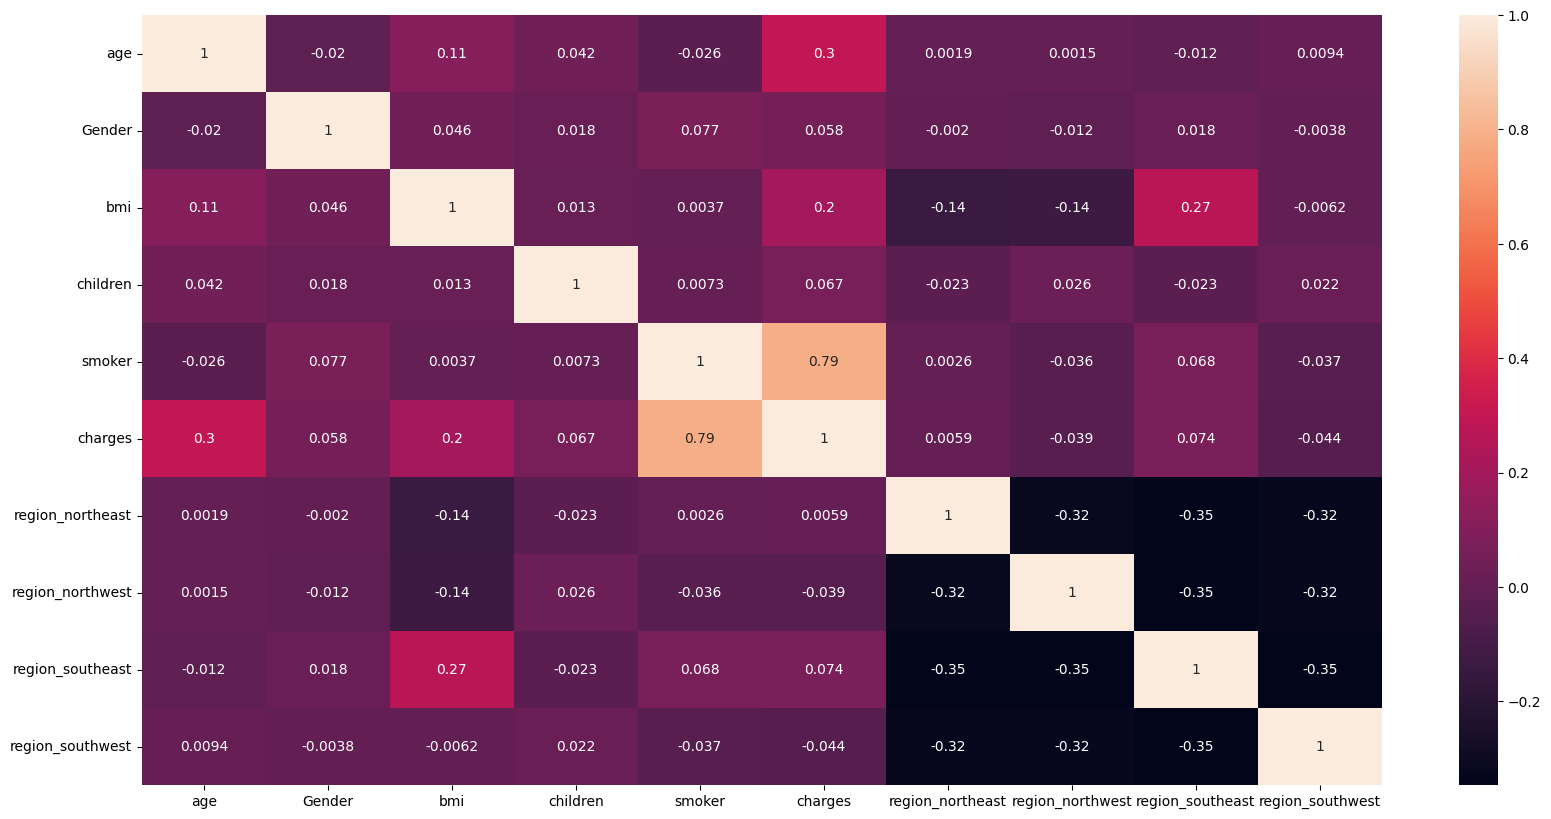

In [19]:
plt.figure(figsize=(20,10))
sns.heatmap(encoder_data.corr(), annot = True)

In [20]:
encoder_data

,age,Gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


In [21]:
# X, y
X = encoder_data.drop(["charges"],axis = 1)
y = encoder_data["charges"]


In [22]:
import numpy as np
np.random.seed(10)
np.random.randint(10)

9

In [23]:
# train test split

from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X,y ,test_size = 0.20, random_state = 42)

In [24]:
#MOdel Selection
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_train_pred = model.predict(X_train)

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [30]:
r2_score(y_train, y_train_pred)

0.7299057809339075

In [31]:
mean_absolute_error(y_train, y_train_pred)

4181.901537775143

In [32]:
y_pred_test =model.predict(X_test)

In [33]:
r2_score(y_test, y_pred_test)

0.8069287081198012

In [34]:
mean_absolute_error(y_test, y_pred_test)

4177.04556103632

In [35]:
from sklearn.linear_model import Lasso, Ridge

In [36]:
l1 = Lasso()

In [37]:
l1.fit(X_train, y_train)

Lasso()

In [39]:
l1_pred_train = l1.predict(X_train)

In [40]:
r2_score(y_train, l1_pred_train)

0.7299055607778382

In [41]:
mean_absolute_error(y_train, l1_pred_train)

4182.196817961823

In [42]:
l2 = Ridge()

In [43]:
l2.fit(X_train, y_train)

Ridge()

In [44]:
l2_pred_train_ridge =l2.predict(X_train)

In [45]:
r2_score(y_train, l2_pred_train_ridge)

0.7298843378768906

In [46]:
mean_absolute_error(y_train, l2_pred_train_ridge)

4190.715099282283